### Compare Segments: Plot LOOCV predictions vs observed values for each watershed/independent variable across segmentation intervals

Region
Watershed
Segment Interval
Independent Variable
stats.bias
stats.MSPE
stats.RMSPE
stats.RAV
cv_predict
se.fit
obs
source_file
RMSPE
Mean Response
SD Response
Mean Residuals
SD Residuals
AIC
Bias
RAV
FileBaseName


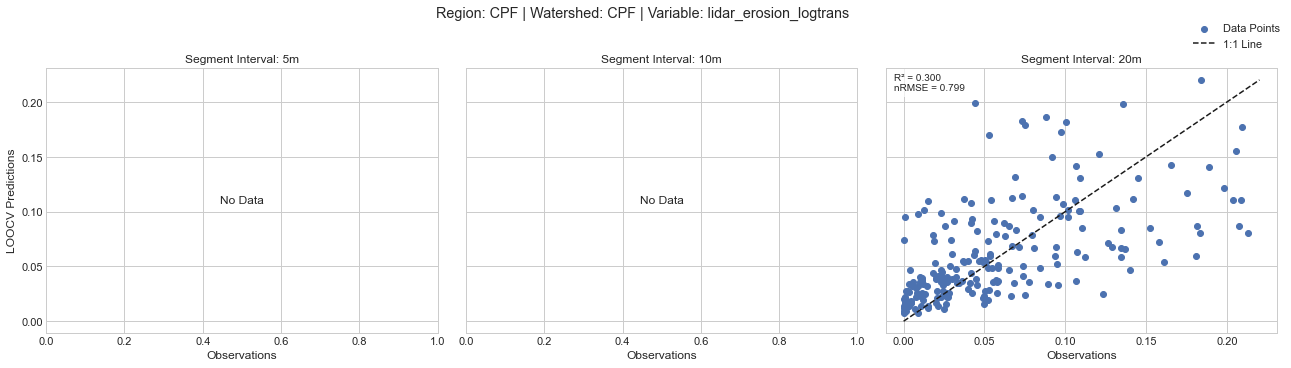

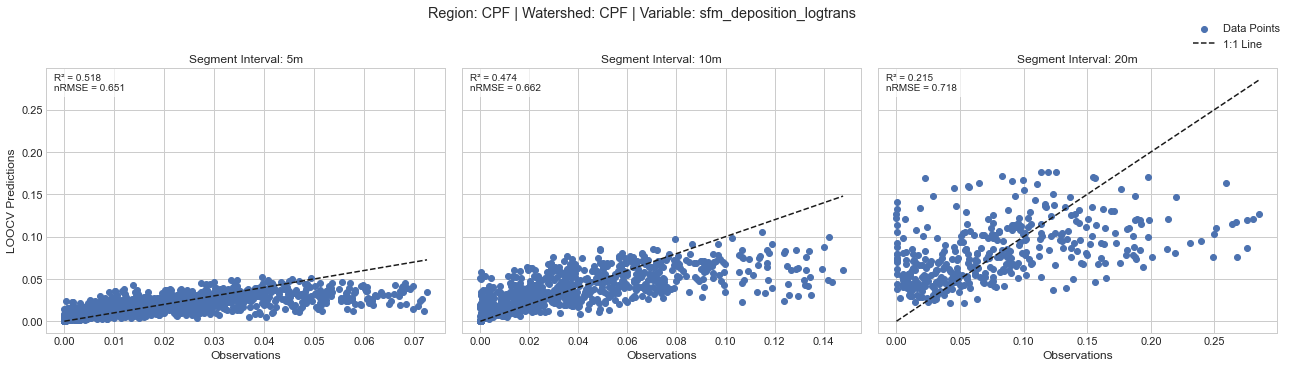

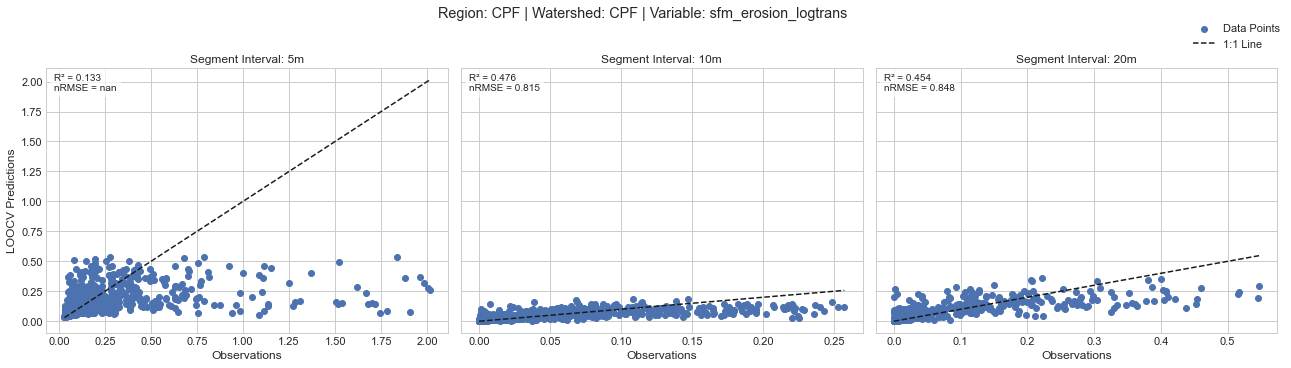

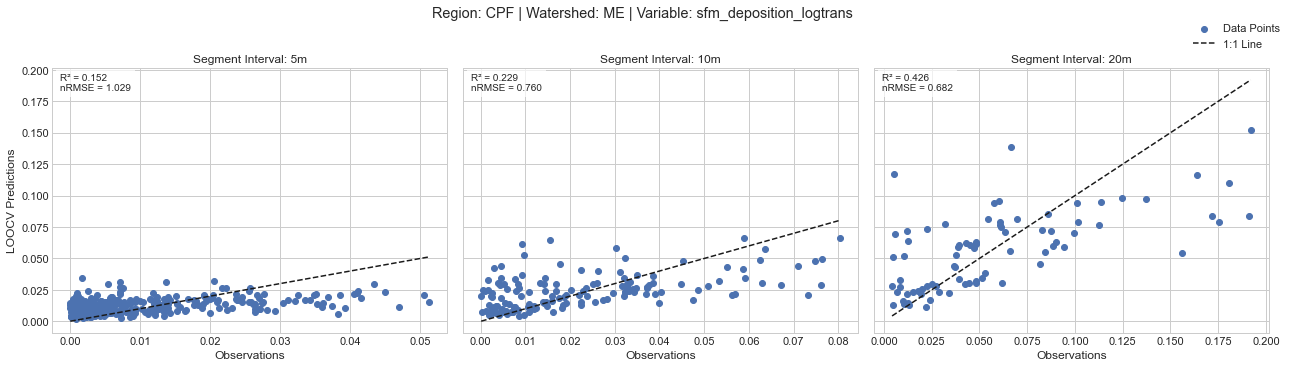

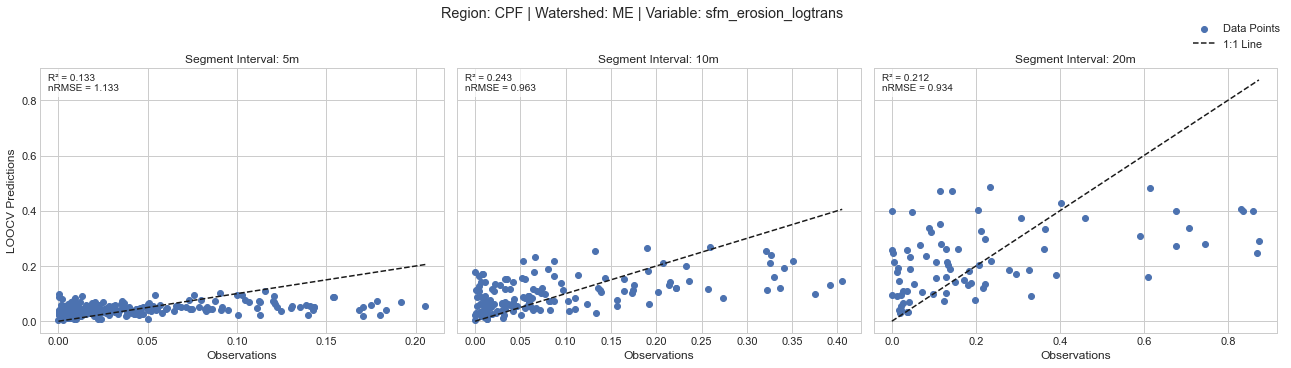

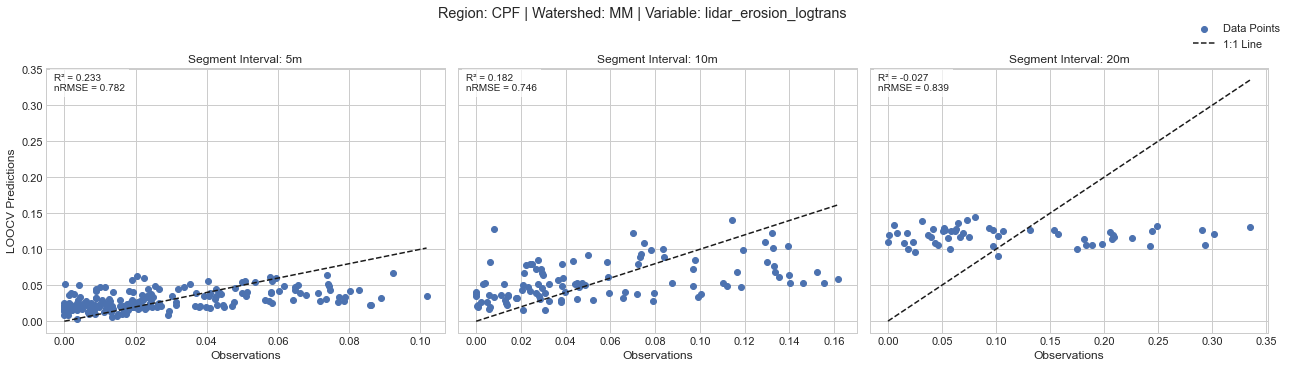

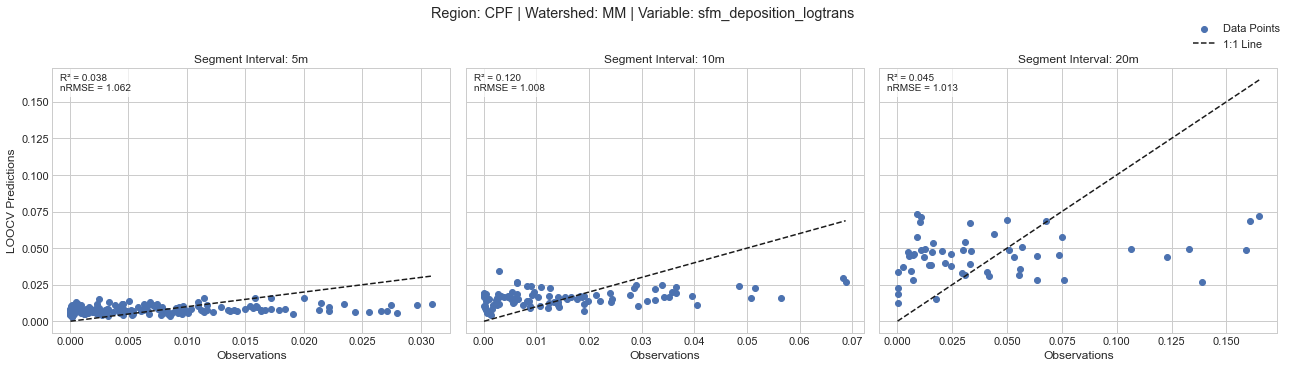

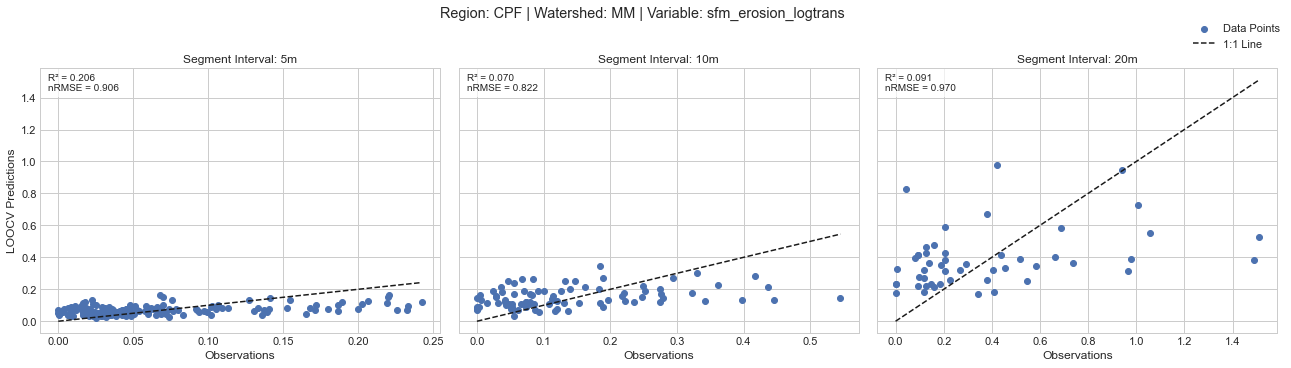

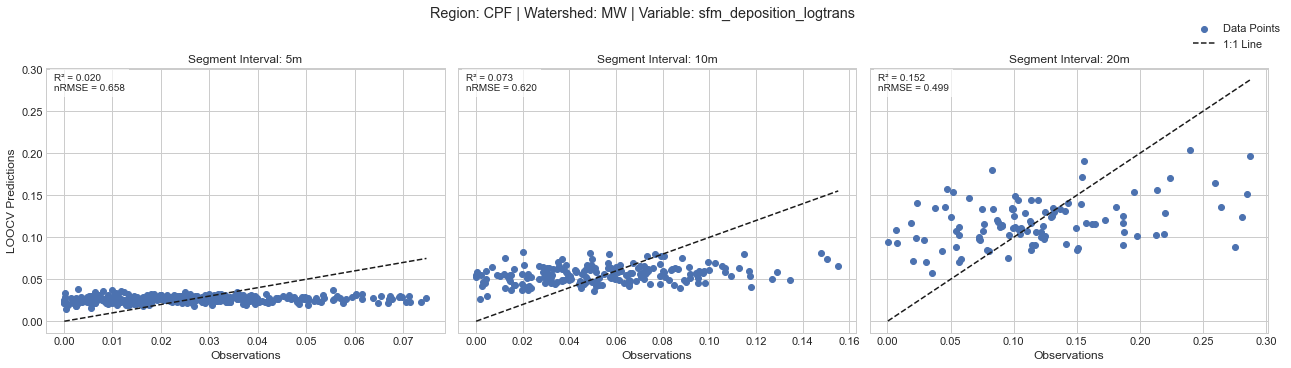

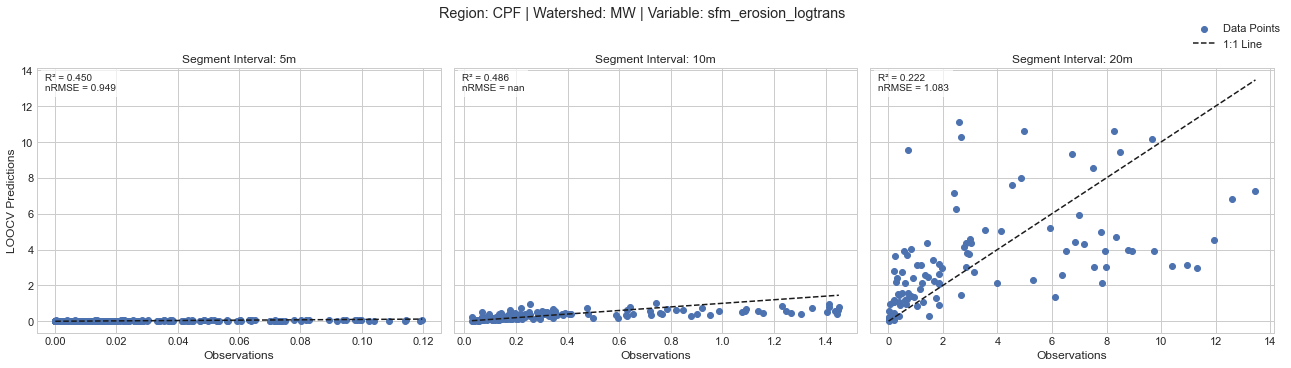

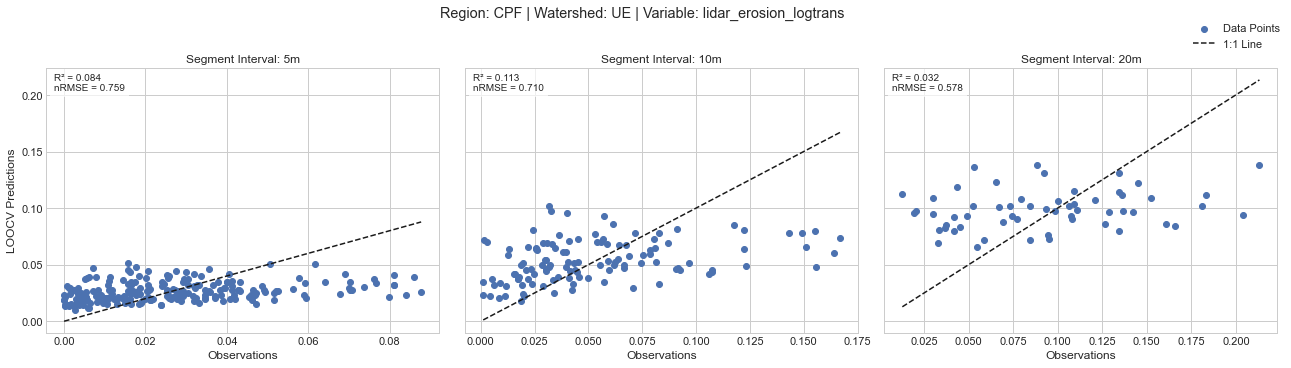

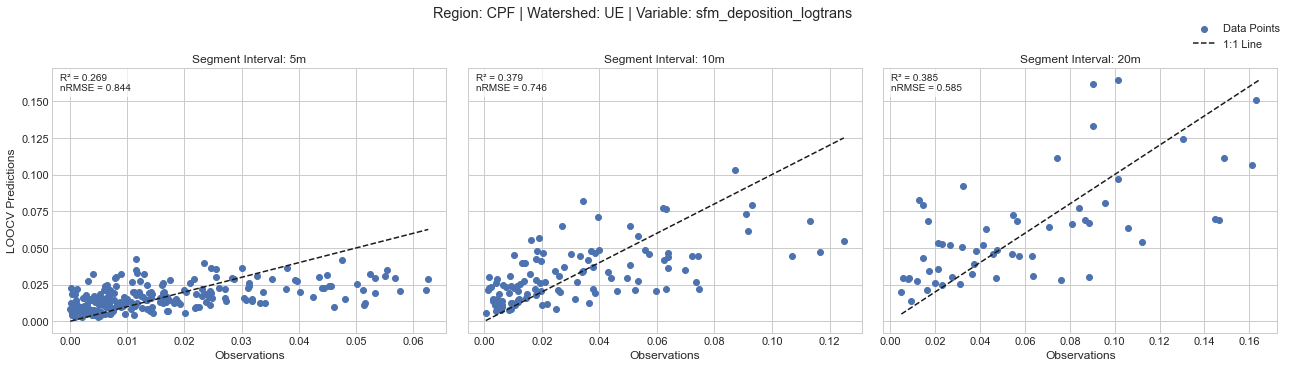

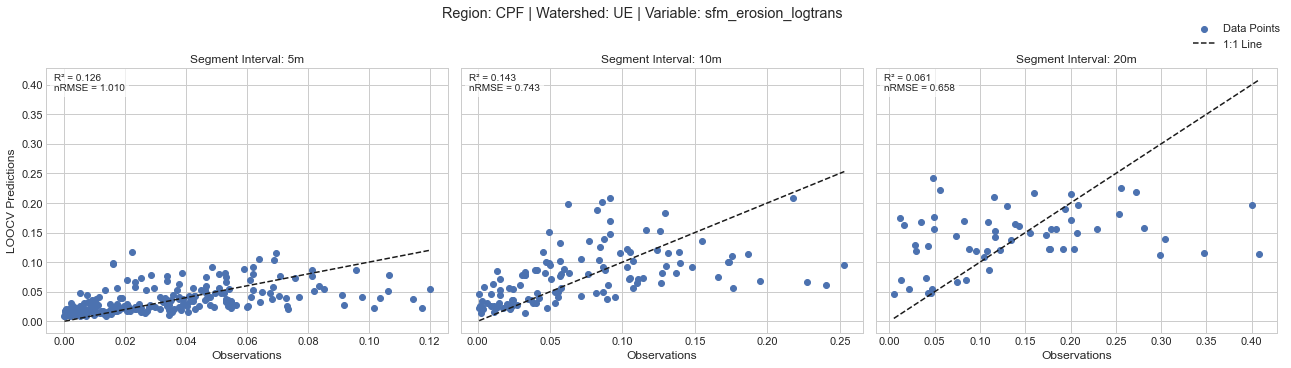

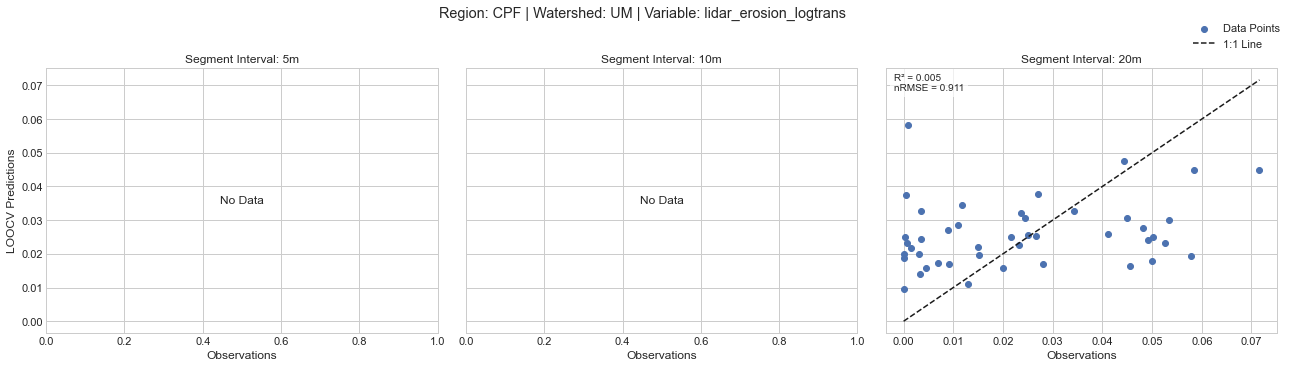

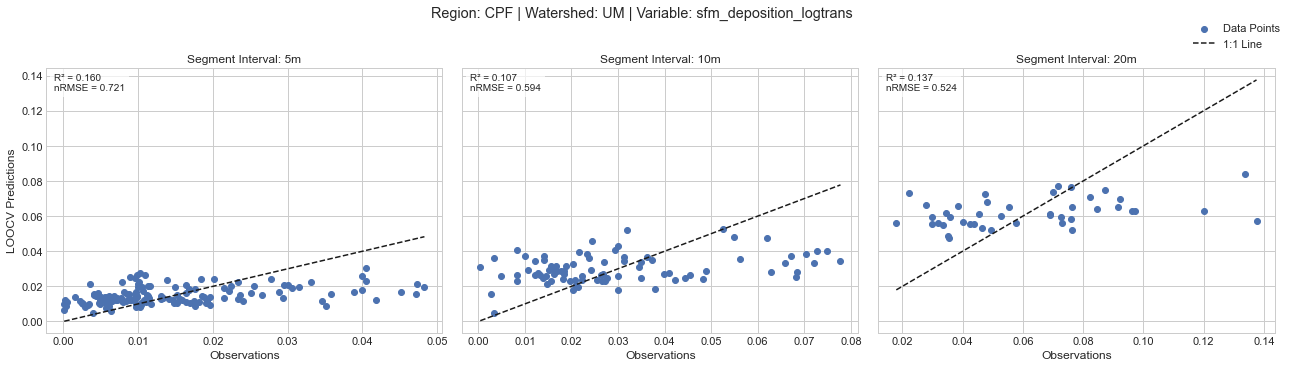

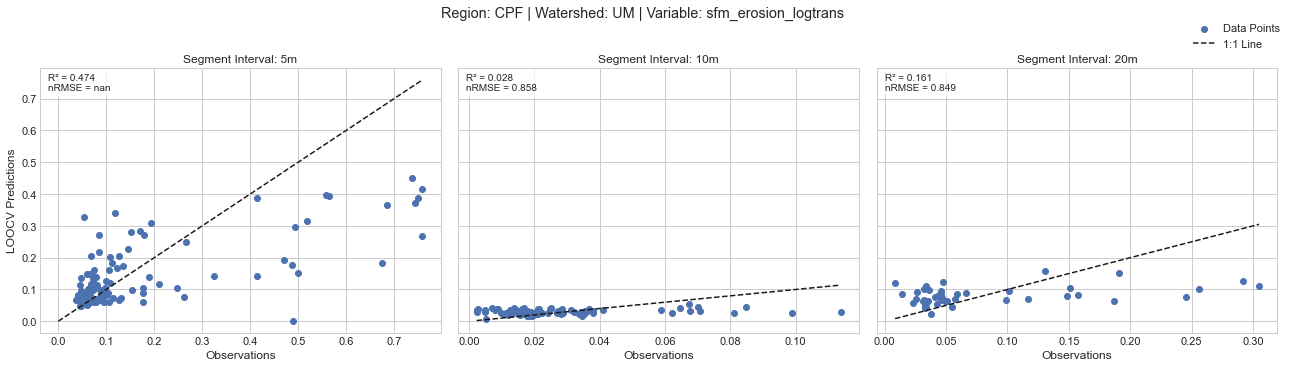

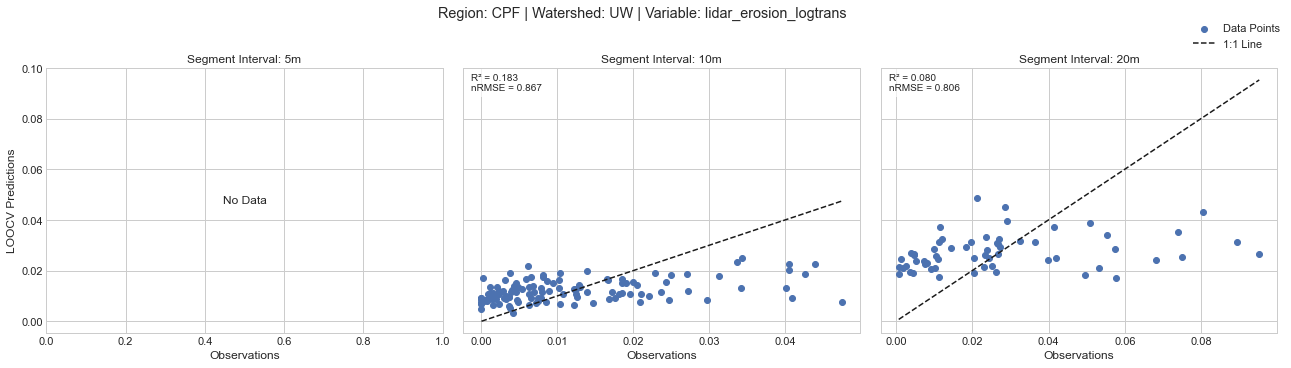

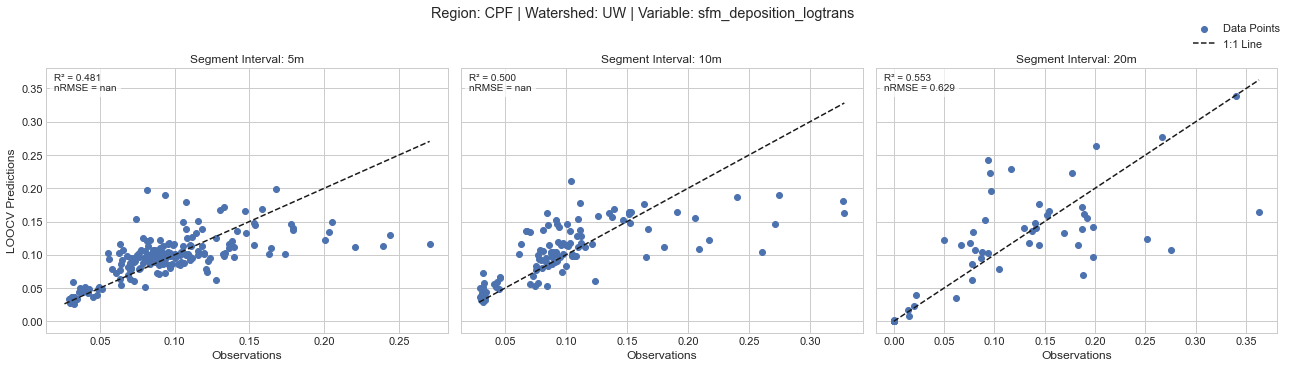

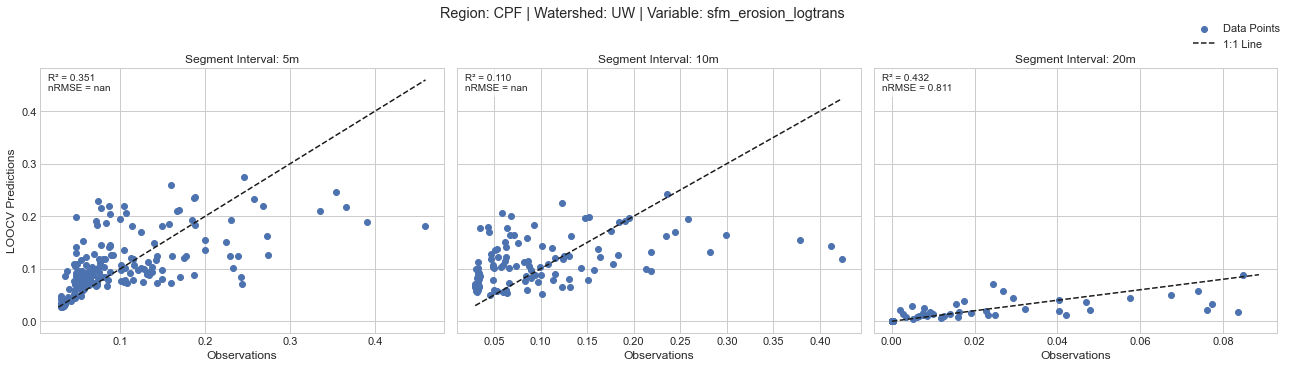

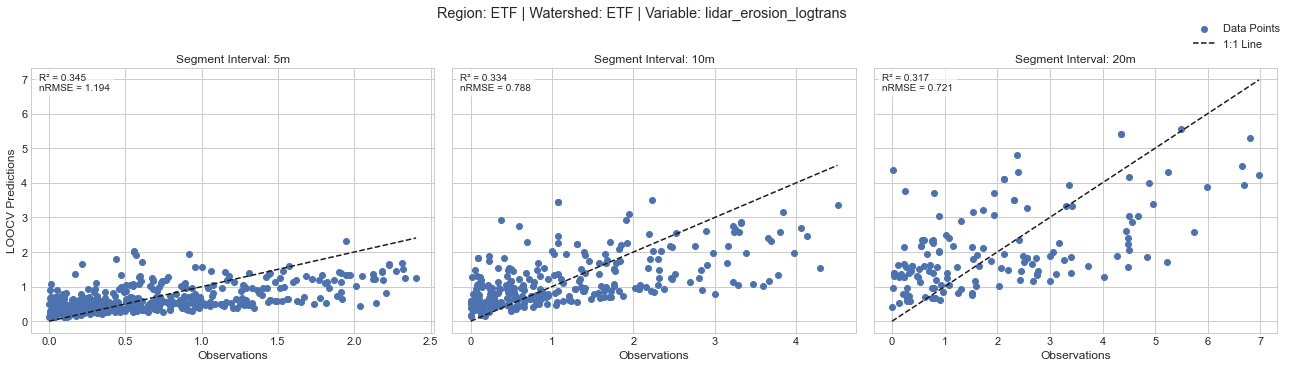

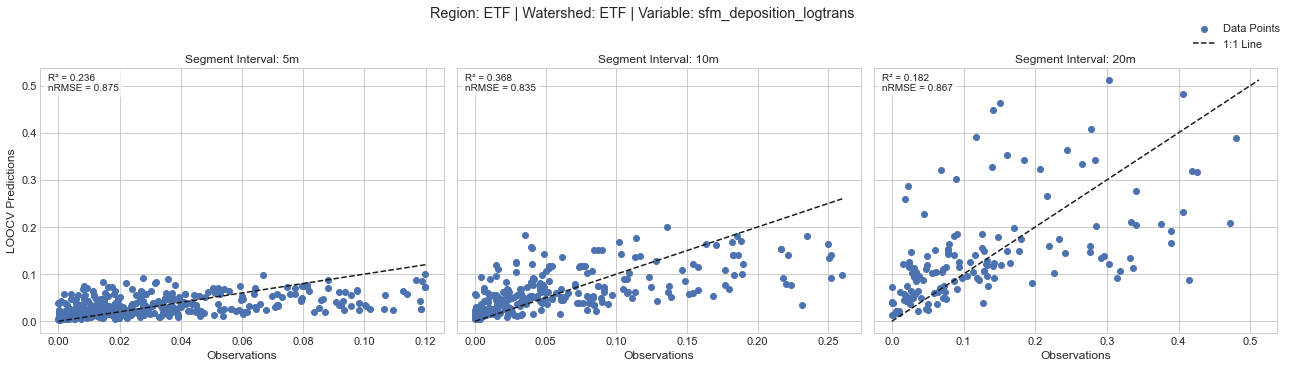

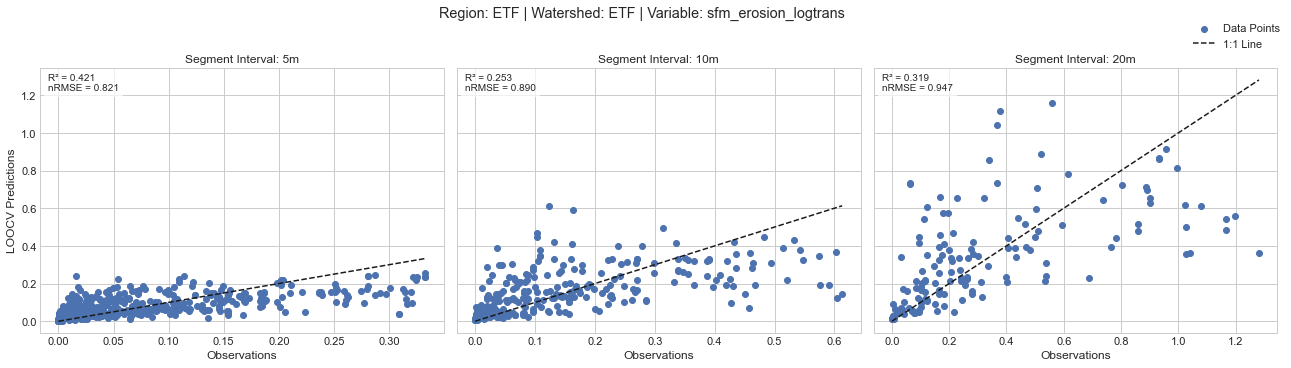

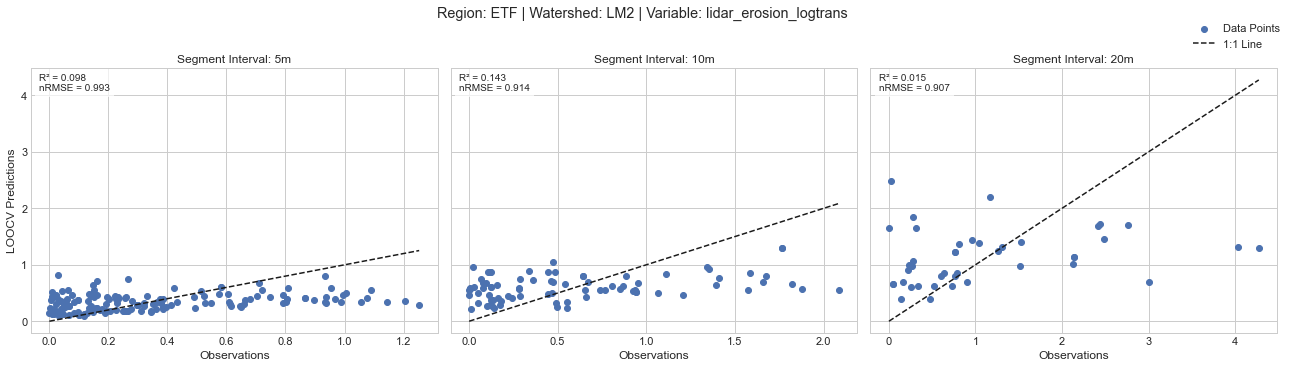

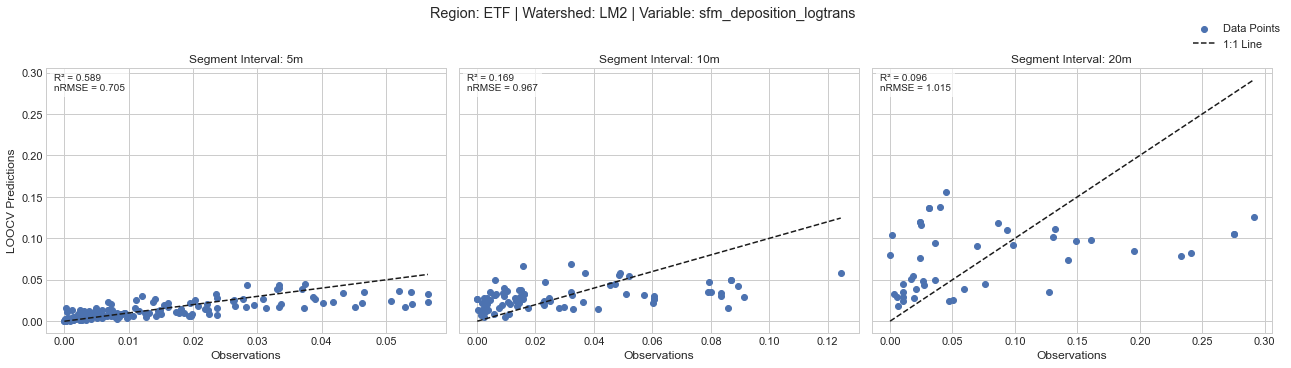

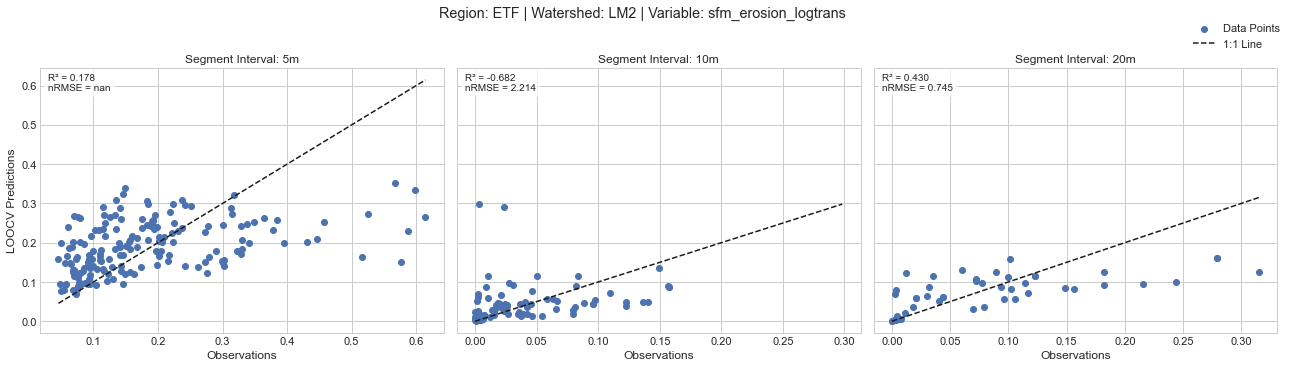

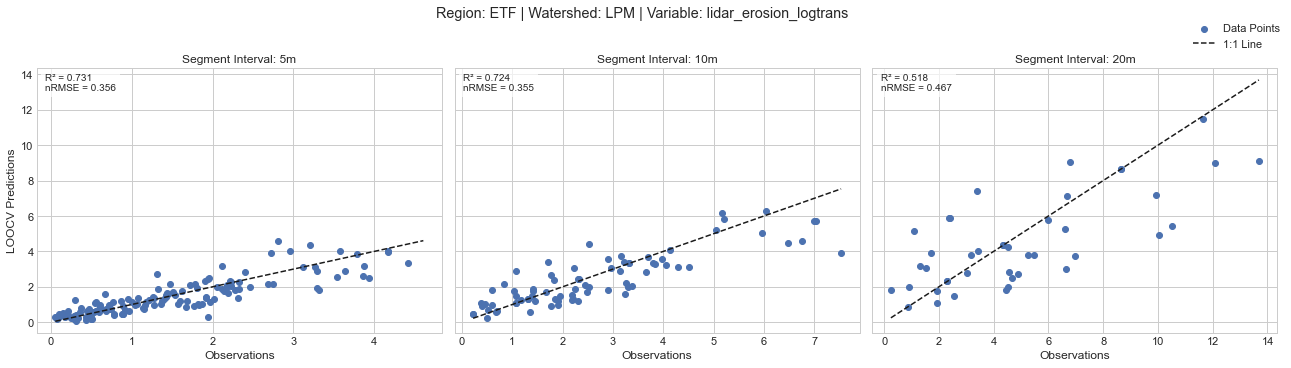

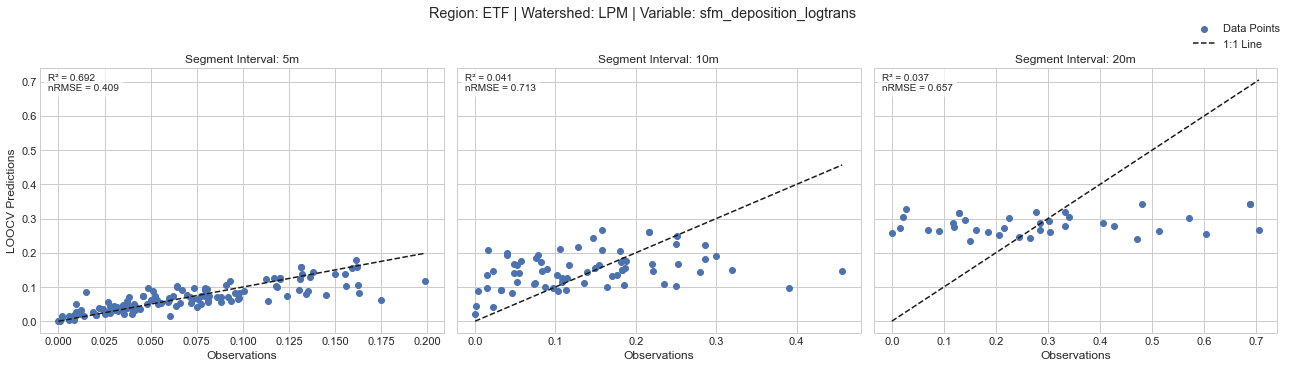

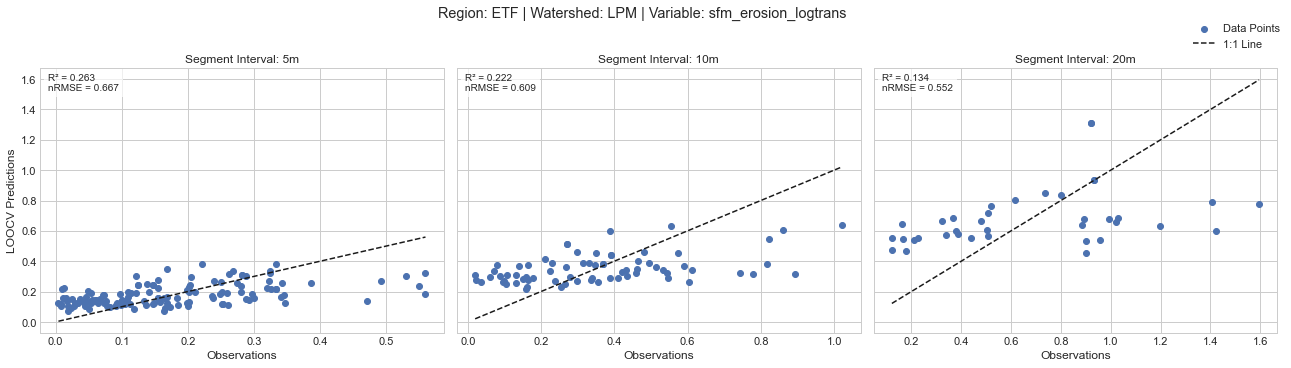

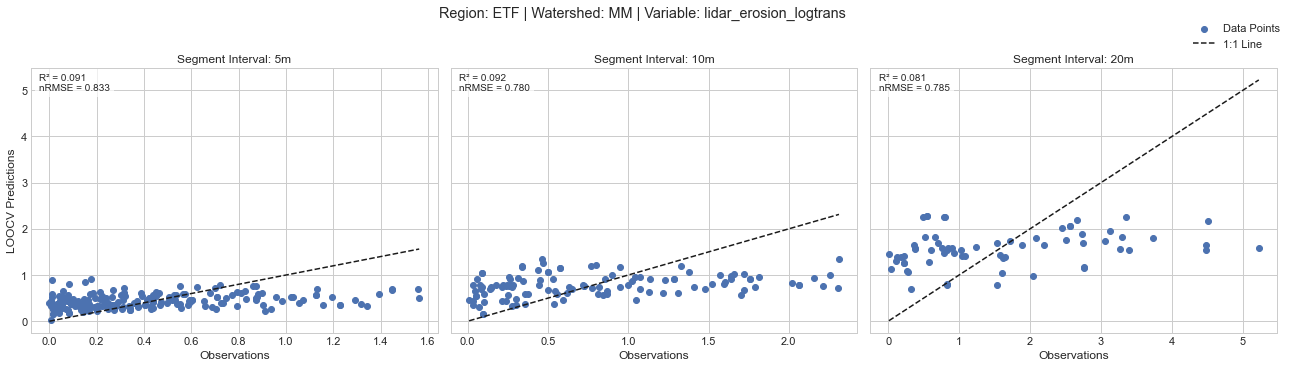

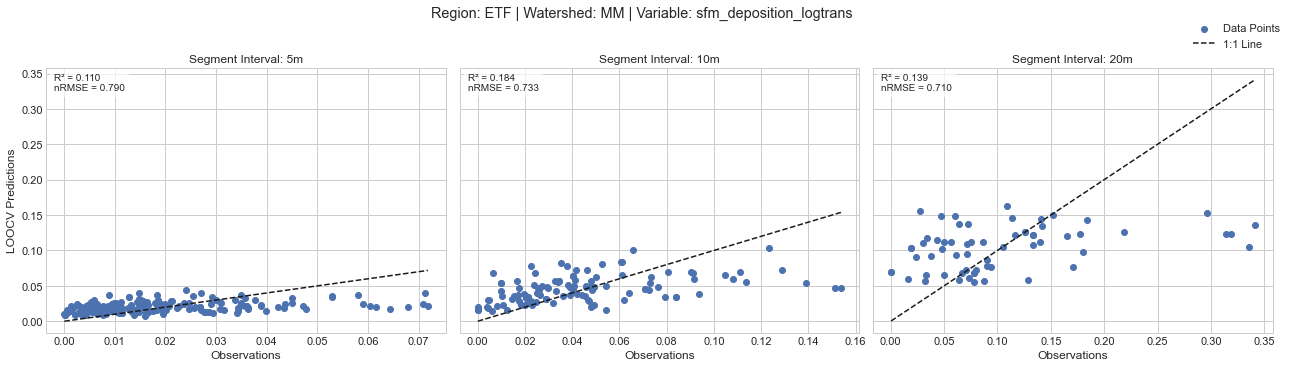

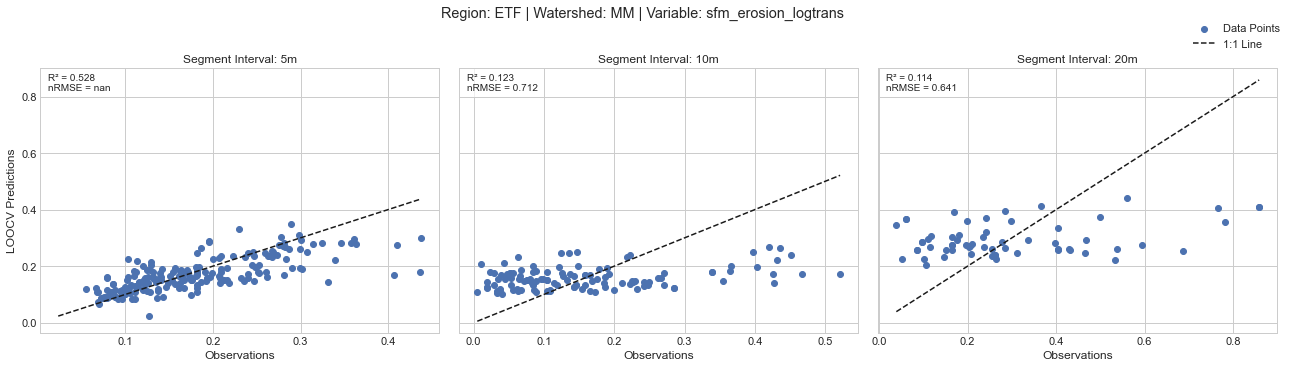

In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_loocv_vs_obs(loocv_prediction_summary, output_dir):
    """
    Reads a tab-delimited data file, then plots LOOCV predictions vs. observations 
    grouped by (Region, Watershed, independent variable). Each figure contains 
    three subplots arranged in a fixed order: Segment Interval "5m" (left), 
    "10m" (middle), and "20m" (right). Outlier predictions—those more than 4 standard
    deviations from the mean of predictions—are removed prior to plotting.
    
    Parameters
    ----------
    loocv_prediction_summary : str
        Path to the tab-delimited data file.
    output_dir : str
        Directory where output plots will be saved.
    """
    os.makedirs(output_dir, exist_ok=True)
    # Read data
    df = pd.read_csv(loocv_prediction_summary)
    df_columns = df.columns.tolist()
    for col in df_columns:
        print(col)
    
    # Create a normalized RMSE column (RMSPE / Mean Response)
    df["normalized_rmse"] = df["RMSPE"] / df["Mean Response"]
    
    # Group by (Region, Watershed, independent variable)
    group_cols = ["Region", "Watershed", "Independent Variable"]
    grouped = df.groupby(group_cols)
    
    # Set a clean plotting style
    plt.style.use("seaborn-whitegrid")
    
    failed_cases = []  # List to record any cases that fail during plotting
    
    # Define the fixed segment order
    fixed_intervals = ["5m", "10m", "20m"]
    
    # Loop over each group
    for (region, watershed, ivar), gdf in grouped:
        if "net" in ivar:
            continue  # Skip net change independent variable
        # Create a figure with three subplots in the fixed order
        fig, axes = plt.subplots(
            nrows=1,
            ncols=len(fixed_intervals),
            figsize=(6 * len(fixed_intervals), 5),
            sharey=True
        )
        
        for ax, seg in zip(axes, fixed_intervals):
            try:
                seg_data = gdf[gdf["Segment Interval"] == seg]
                
                # If there is no data for the current segment interval, indicate it and skip plotting.
                if seg_data.empty:
                    ax.text(0.5, 0.5, "No Data", transform=ax.transAxes,
                            ha='center', va='center')
                    ax.set_title(f"Segment Interval: {seg}")
                    ax.set_xlabel("Observations")
                    if ax == axes[0]:
                        ax.set_ylabel("LOOCV Predictions")
                    continue
                
                # Filter out predictions more than 3 std deviations from the mean
                mean_pred = seg_data["cv_predict"].mean()
                std_pred = seg_data["cv_predict"].std()
                lower_bound = mean_pred - 3 * std_pred
                upper_bound = mean_pred + 3 * std_pred
                seg_data = seg_data[(seg_data["cv_predict"] >= lower_bound) &
                                    (seg_data["cv_predict"] <= upper_bound)]
                
                #Filter out observations more than 3 std deviations from the mean
                mean_obs = seg_data["obs"].mean()
                std_obs = seg_data["obs"].std()
                lower_bound = mean_obs - 3 * std_obs
                upper_bound = mean_obs + 3 * std_obs
                seg_data = seg_data[(seg_data["obs"] >= lower_bound) &
                                    (seg_data["obs"] <= upper_bound)]
                
                # Create scatter plot: x=observations, y=LOOCV predictions
                ax.scatter(seg_data["obs"], seg_data["cv_predict"], marker='o', label="Data Points")
                
                # Plot the 1:1 line for reference
                min_val = min(seg_data["obs"].min(), seg_data["cv_predict"].min())
                max_val = max(seg_data["obs"].max(), seg_data["cv_predict"].max())
                ax.plot([min_val, max_val], [min_val, max_val], 'k--', label="1:1 Line")
                
                # Compute R² and normalized RMSE
                r2 = r2_score(seg_data["obs"], seg_data["cv_predict"])
                nrmse = seg_data["normalized_rmse"].mean()
                
                # Annotate subplot with performance metrics
                ax.text(
                    0.02, 0.98,
                    f"R² = {r2:.3f}\nnRMSE = {nrmse:.3f}",
                    transform=ax.transAxes,
                    ha='left', va='top',
                    fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                )
                
                ax.set_title(f"Segment Interval: {seg}")
                ax.set_xlabel("Observations")
                if ax == axes[0]:
                    ax.set_ylabel("LOOCV Predictions")
            except Exception as e:
                # Record any failure with its group and segment interval information
                failed_cases.append((region, watershed, ivar, seg, str(e)))
        
        # Add a common legend using handles from the last subplot
        handles, labels = axes[-1].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1, 1))
        fig.suptitle(f"Region: {region} | Watershed: {watershed} | Variable: {ivar}", y=1.02)
        fig.tight_layout()
        
        # Save and display the figure
        output_file = os.path.join(output_dir, f"loocv_vs_obs_{region}_{watershed}_{ivar}.png")
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        plt.show()
    
    # After processing all groups, print any cases that failed
    if failed_cases:
        print("The following cases failed during plotting:")
        for case in failed_cases:
            region, watershed, ivar, seg, error_msg = case
            print(f"Region: {region}, Watershed: {watershed}, Variable: {ivar}, Segment Interval: {seg} -> Error: {error_msg}")

# Example usage
plot_loocv_vs_obs(r"Results Summary\loocv_prediction_summary.csv",
                  r"Results Summary\loocv_prediction_plots")


## Plot Predictor Estimates with SSN CI

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_regression_importance(csv_path, output_dir="plots"):
    """
    Reads a CSV of regression results, filters for p.value < 0.05 (omitting intercept),
    and creates paneled plots with confidence bars and color-coded p-value dots using seaborn.
    """
    sns.set_theme(style="whitegrid")
    os.makedirs(output_dir, exist_ok=True)
    
    # Read CSV and filter
    df = pd.read_csv(csv_path)
    df = df[df['Dependent Variable'] != '(Intercept)']
    df = df[df['p.value'] < 0.05]
    
    df.rename(columns={
        'Mean Response': 'Mean_Response',
        'pseudo.R.squared': 'pseudo_r2'
    }, inplace=True)
    
    # Define p-value categories and color palette
    p_value_bins = [0, 0.01, 0.05, 0.10]
    p_value_labels = ['p < 0.01', '0.01 ≤ p < 0.05', '0.05 ≤ p < 0.10']
    df['p.value.category'] = pd.cut(df['p.value'], bins=p_value_bins, labels=p_value_labels, include_lowest=True)
    
    # Updated color palette: dark blue, light blue, and white.
    color_dict = {
        'p < 0.01': "#00008B",         # dark blue
        '0.01 ≤ p < 0.05': "#ADD8E6",    # light blue
        '0.05 ≤ p < 0.10': "#FFFFFF"     # white
    }
    
    # Map independent variable names: underscores to spaces and title-case
    df['ind_var_mapped'] = df['Independent Variable'].apply(lambda x: x.replace("_", " ").title())
    
    def plot_grouped_watersheds(subset_df, watersheds, region_label, ind_var_label,
                                nrows, ncols, segment_interval, plot_title_prefix):
        # If entire subset is empty, generate a single plot with message.
        if subset_df.empty or len(watersheds) == 0:
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.text(0.5, 0.5, "No Significant Predictors",
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes, fontsize=20, color='red')
            ax.set_xticks([])
            ax.set_yticks([])
            out_name = f"{plot_title_prefix}_{region_label}_{ind_var_label}_{segment_interval}.png"
            out_path = os.path.join(output_dir, out_name)
            plt.savefig(out_path, dpi=300, bbox_inches='tight')
            plt.close(fig)
            print(f"Saved: {out_path}")
            return
        
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12*ncols, 8*nrows), sharex=False)
        axes = axes.flatten()
        n_plots = len(watersheds)
        x_axis_min = float('inf')
        x_axis_max = float('-inf')
        for ws in watersheds:
            ws_data = subset_df[subset_df['Watershed'] == ws].copy()
            if not ws_data.empty:
                x_axis_min = min(x_axis_min, ws_data['conf.low'].min()-0.05)
                x_axis_max = max(x_axis_max, ws_data['conf.high'].max()+0.05)
                
        for ax_idx, ws in enumerate(watersheds):
            ax = axes[ax_idx]
            ws_data = subset_df[subset_df['Watershed'] == ws].copy()
            ws_data.sort_values('estimate', inplace=True)
            
            if ws_data.empty:
                ax.text(0.5, 0.5, "No Significant Predictors",
                        horizontalalignment='center', verticalalignment='center',
                        transform=ax.transAxes, fontsize=20, color='red')
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_title(f"{ws}", fontsize=24, fontweight='bold')
                ax.set_ylabel("")
                continue
            
            # Plot confidence intervals
            ax.errorbar(
                x=ws_data['estimate'],
                y=ws_data['Dependent Variable'],
                xerr=[ws_data['estimate'] - ws_data['conf.low'], ws_data['conf.high'] - ws_data['estimate']],
                fmt='none',
                ecolor='gray',
                elinewidth=2,
                capsize=5,
                capthick=2
            )
            
            # Plot scatter points colored by p.value.category
            sns.scatterplot(
                x='estimate',
                y='Dependent Variable',
                hue='p.value.category',
                data=ws_data,
                palette=color_dict,
                edgecolor='black',
                s=300,
                ax=ax,
                legend=False,
                zorder=5
            )
            ax.set_xlim(x_axis_min, x_axis_max)
            ax.axvline(0, color='grey', linewidth=1, linestyle='--')
            ax.invert_yaxis()
            ax.set_ylabel("")  # Remove y-axis label
            
            # Annotate with pseudo-R² and nRMSE if data exists
            first_row = ws_data.iloc[0]
            r2_val = first_row['pseudo_r2'] if pd.notnull(first_row['pseudo_r2']) else float('nan')
            if pd.notnull(first_row['RMSPE']) and pd.notnull(first_row['Mean_Response']) and first_row['Mean_Response'] != 0:
                nrmse = first_row['RMSPE'] / first_row['Mean_Response']
            else:
                nrmse = float('nan')
            
            ax.text(
                0.05, 0.95,
                f'R²: {r2_val:.4f}\nnRMSE: {nrmse:.4f}',
                horizontalalignment='left',
                verticalalignment='top',
                transform=ax.transAxes,
                fontsize=16,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                zorder=10
            )
            
            ax.set_title(f"{ws}", fontsize=24, fontweight='bold')
            ax.tick_params(axis='y', labelsize=20)
            ax.tick_params(axis='x', labelsize=18)
            # Always set x-axis label and ticks for plots with significant predictors
            ax.set_xlabel("Importance", fontsize=20)
            ax.xaxis.set_tick_params(labelbottom=True)
        
        # Remove any unused subplots
        for ax_idx in range(n_plots, nrows * ncols):
            fig.delaxes(axes[ax_idx])
        
        # Create a single legend for the figure
        handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color_dict[cat],
                       markeredgecolor='black',
                       markersize=15)
            for cat in p_value_labels
        ]
        fig.legend(handles, p_value_labels, bbox_to_anchor=(0.5, 1.06),
                   loc='upper center', ncol=len(p_value_labels), fontsize=18)
        
        plt.tight_layout(rect=[0, 0.03, 1, 1])
        out_name = f"{plot_title_prefix}_{region_label}_{ind_var_label}_{segment_interval}.png"
        out_path = os.path.join(output_dir, out_name)
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {out_path}")
    
    def plot_grouped_watersheds_ivars(subset_df, watersheds, ivar_list, region_label,
                                      segment_interval, plot_title_prefix):
        """
        Creates a grid of subplots with rows for each watershed and columns for each independent variable.
        It plots confidence intervals and scatter points as in the other plotting function.
        """
        nrows = len(watersheds)
        ncols = len(ivar_list)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12*ncols, 8*nrows), sharex=False)
        
        # Ensure axes is 2D
        if nrows == 1 and ncols == 1:
            axes = [[axes]]
        elif nrows == 1:
            axes = [axes]
        elif ncols == 1:
            axes = [[ax] for ax in axes]
        x_axis_min = float('inf')
        x_axis_max = float('-inf')
        for ws in watersheds:
            for iv in ivar_list:
                ws_iv_data = subset_df[(subset_df['Watershed'] == ws) & 
                                       (subset_df['Independent Variable'].str.lower() == iv)]
                if not ws_iv_data.empty:
                    x_axis_min = min(x_axis_min, ws_iv_data['conf.low'].min()-0.05)
                    x_axis_max = max(x_axis_max, ws_iv_data['conf.high'].max()+0.05)
        for i, ws in enumerate(watersheds):
            for j, iv in enumerate(ivar_list):
                ax = axes[i][j]
                # Filter data for watershed ws and independent variable iv (exact match using lower case)
                ws_iv_data = subset_df[(subset_df['Watershed'] == ws) & 
                                       (subset_df['Independent Variable'].str.lower() == iv)]
                ws_iv_data.sort_values('estimate', inplace=True)
                
                if ws_iv_data.empty:
                    ax.text(0.5, 0.5, "No Significant Predictors",
                            horizontalalignment='center', verticalalignment='center',
                            transform=ax.transAxes, fontsize=20, color='red')
                    ax.set_xticks([])
                    ax.set_yticks([])
                    iv_mapped = iv.replace("_", " ").title()
                    ax.set_title(f"{ws} - {iv_mapped}", fontsize=24, fontweight='bold')
                    ax.set_ylabel("")
                    continue
                
                # Plot confidence intervals
                ax.errorbar(
                    x=ws_iv_data['estimate'],
                    y=ws_iv_data['Dependent Variable'],
                    xerr=[ws_iv_data['estimate'] - ws_iv_data['conf.low'], ws_iv_data['conf.high'] - ws_iv_data['estimate']],
                    fmt='none',
                    ecolor='gray',
                    elinewidth=2,
                    capsize=5,
                    capthick=2
                )
                
                # Plot scatter points colored by p.value.category
                sns.scatterplot(
                    x='estimate',
                    y='Dependent Variable',
                    hue='p.value.category',
                    data=ws_iv_data,
                    palette=color_dict,
                    edgecolor='black',
                    s=300,
                    ax=ax,
                    legend=False,
                    zorder=5
                )
                ax.set_xlim(x_axis_min, x_axis_max)
                ax.axvline(0, color='grey', linewidth=1, linestyle='--')
                ax.invert_yaxis()
                ax.set_ylabel("")
                
                first_row = ws_iv_data.iloc[0]
                r2_val = first_row['pseudo_r2'] if pd.notnull(first_row['pseudo_r2']) else float('nan')
                if pd.notnull(first_row['RMSPE']) and pd.notnull(first_row['Mean_Response']) and first_row['Mean_Response'] != 0:
                    nrmse = first_row['RMSPE'] / first_row['Mean_Response']
                else:
                    nrmse = float('nan')
                
                ax.text(
                    0.05, 0.95,
                    f'R²: {r2_val:.4f}\nnRMSE: {nrmse:.4f}',
                    horizontalalignment='left',
                    verticalalignment='top',
                    transform=ax.transAxes,
                    fontsize=16,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
                    zorder=10
                )
                
                iv_mapped = iv.replace("_", " ").title()
                ax.set_title(f"{ws} - {iv_mapped}", fontsize=24, fontweight='bold')
                ax.tick_params(axis='y', labelsize=20)
                ax.tick_params(axis='x', labelsize=18)
                # Always set x-axis label and tick marks for plots with significant predictors
                ax.set_xlabel("Importance", fontsize=20)
                ax.xaxis.set_tick_params(labelbottom=True)
        
        # Create a single legend for the figure
        flat_axes = []
        for row in axes:
            flat_axes.extend(row)
        handles = [
            plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color_dict[cat],
                       markeredgecolor='black',
                       markersize=15)
            for cat in p_value_labels
        ]
        fig.legend(handles, p_value_labels, bbox_to_anchor=(0.5, 1.06),
                   loc='upper center', ncol=len(p_value_labels), fontsize=18)
        
        plt.tight_layout(rect=[0, 0.03, 1, 1])
        out_name = f"{plot_title_prefix}_{region_label}_{segment_interval}.png"
        out_path = os.path.join(output_dir, out_name)
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {out_path}")
    
    # Loop over each segment interval and independent variable
    for seg_int in sorted(df['Segment Interval'].unique()):
        seg_data = df[df['Segment Interval'] == seg_int]
        
        for ivar in sorted(seg_data['ind_var_mapped'].unique()):
            # Process CPF region: if the variable name contains "lidar", only plot selected watersheds in 2x2
            cpf_subset = seg_data[seg_data['Region'] == 'CPF']
            if not cpf_subset.empty:
                if "lidar" in ivar.lower():
                    cpf_watersheds = ['MM', 'UE', 'UM', 'UW']
                    nrows, ncols = 2, 2
                else:
                    cpf_watersheds = ['ME', 'MM', 'MW', 'UE', 'UM', 'UW']
                    nrows, ncols = 2, 3
                subset_cpf = cpf_subset[
                    (cpf_subset['ind_var_mapped'] == ivar) &
                    (cpf_subset['Watershed'].isin(cpf_watersheds))
                ]
                plot_grouped_watersheds(
                    subset_cpf, cpf_watersheds, 'CPF', ivar, 
                    nrows=nrows, ncols=ncols, 
                    segment_interval=seg_int,
                    plot_title_prefix="Watershed_CPF"
                )
            
            # Process ETF region
            etf_subset = seg_data[seg_data['Region'] == 'ETF']
            if not etf_subset.empty:
                etf_watersheds = ['LM2', 'LPM', 'MM']
                subset_etf = etf_subset[
                    (etf_subset['ind_var_mapped'] == ivar) &
                    (etf_subset['Watershed'].isin(etf_watersheds))
                ]
                plot_grouped_watersheds(
                    subset_etf, etf_watersheds, 'ETF', ivar, 
                    nrows=2, ncols=2, 
                    segment_interval=seg_int,
                    plot_title_prefix="Watershed_ETF"
                )
        
        # Additional plots based on independent variable content and watershed codes
        
        # 1. Erosion group: For ETF and CPF, plot "lidar_erosion_logtrans" and "sfm_erosion_logtrans" in a 2x2 grid
        erosion_ivars = ["lidar_erosion_logtrans", "sfm_erosion_logtrans"]
        subset_erosion = seg_data[
            (seg_data['Watershed'].isin(['CPF', 'ETF'])) &
            (seg_data['Independent Variable'].str.lower().isin(erosion_ivars))
        ]
        plot_grouped_watersheds_ivars(
            subset_erosion, 
            watersheds=['CPF', 'ETF'], 
            ivar_list=erosion_ivars, 
            region_label='CPF_ETF', 
            segment_interval=seg_int, 
            plot_title_prefix="Region_erosion"
        )
        
        # 2. Deposition/Net Change group: For ETF and CPF, plot "sfm_deposition_logtrans" and "sfm_net_change_logtrans" in a 2x2 grid
        dep_ivars = ["sfm_deposition_logtrans", "sfm_net_change_logtrans"]
        subset_dep = seg_data[
            (seg_data['Watershed'].isin(['CPF', 'ETF'])) &
            (seg_data['Independent Variable'].str.lower().isin(dep_ivars))
        ]
        plot_grouped_watersheds_ivars(
            subset_dep, 
            watersheds=['CPF', 'ETF'], 
            ivar_list=dep_ivars, 
            region_label='CPF_ETF', 
            segment_interval=seg_int, 
            plot_title_prefix="Region_dep_net"
        )
    
    print("All requested plots have been generated.")

# File paths
csv_file = r"Results Summary\full_results_summary.csv"
output_folder = r"Results Summary\Prediction_Importance_Plots"
os.makedirs(output_folder, exist_ok=True)
plot_regression_importance(csv_file, output_folder)


Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Lidar Erosion Logtrans_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Lidar Erosion Logtrans_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Deposition Logtrans_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Deposition Logtrans_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Erosion Logtrans_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Erosion Logtrans_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Net Change Logtrans_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Net Change Logtrans_10m.png


C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

Saved: Results Summary\Prediction_Importance_Plots\Region_erosion_CPF_ETF_10m.png


C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

Saved: Results Summary\Prediction_Importance_Plots\Region_dep_net_CPF_ETF_10m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Lidar Erosion Logtrans_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Lidar Erosion Logtrans_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Deposition Logtrans_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Deposition Logtrans_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Erosion Logtrans_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Erosion Logtrans_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Net Change Logtrans_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Net Change Logtrans_20m.png


...

Saved: Results Summary\Prediction_Importance_Plots\Region_dep_net_CPF_ETF_20m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Lidar Erosion Logtrans_5m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Lidar Erosion Logtrans_5m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Deposition Logtrans_5m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Deposition Logtrans_5m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Erosion Logtrans_5m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Erosion Logtrans_5m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_CPF_CPF_Sfm Net Change Logtrans_5m.png
Saved: Results Summary\Prediction_Importance_Plots\Watershed_ETF_ETF_Sfm Net Change Logtrans_5m.png


C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

Saved: Results Summary\Prediction_Importance_Plots\Region_erosion_CPF_ETF_5m.png


C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_iv_data.sort_values('estimate', inplace=True)
C:\Users\alextd\AppData\Local\Temp\7\ipykernel_40012\2544498416.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

Saved: Results Summary\Prediction_Importance_Plots\Region_dep_net_CPF_ETF_5m.png
All requested plots have been generated.


## Plot Varcomp

In [31]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

def process_files(aggregated_varcomp_csv, output_varcomp_plot):
    """
    Processes all text files in the input folder, extracts varcomp data, writes to Excel,
    and generates a variance composition bar chart.

    Parameters:
        input_folder (str): Path to the directory containing input text files.
        output_excel (str): Path for the output Excel file.
        output_varcomp_plot (str): Path for the output plot image file.
    """
    # Use glob to find all .txt files in the input directory
    combined_df = pd.read_csv(aggregated_varcomp_csv, sep='\t', header=None, 
                            names=['Region', 'Watershed', 
                                   'Segment Interval', 'Independent variable',
                                   'varcomp', 'proportion'])
        

        
    # Replace variable names with more descriptive names
    combined_df['varcomp'] = combined_df['varcomp'].replace({
        'tailup_de': 'Tailup', 
        'taildown_de': 'Taildown', 
        'nugget': 'Nugget', 
        'Covariates (PR-sq)': 'Covariates',
        '1 | as.factor(ch_watershed)': 'Watershed Random Effect',
        'euclid_de': 'Euclidean',
    })

    try:
        # Write the combined DataFrame to an Excel file
        combined_df.to_excel(output_excel, index=False, engine='openpyxl')
        print(f"Data successfully written to {output_excel}")
    except Exception as e:
        print(f"Error writing to Excel: {e}")

    # Plotting the variance composition
    try:
        plot_varcomp(combined_df, output_varcomp_plot)
        print(f"Variance composition bar chart saved to {output_varcomp_plot}")
    except Exception as e:
        print(f"Error generating plot: {e}")
    else:
        print("No varcomp data extracted from any files.")

def plot_varcomp(df, output_varcomp_plot):
    """
    Generates and saves a bar chart of variance composition grouped by study area.

    Parameters:
        df (pd.DataFrame): DataFrame containing 'study area', 'varcomp', and 'proportion'.
        output_varcomp_plot (str): Path to save the bar chart image.
    """
    # Pivot the DataFrame to have study areas as groups and varcomp categories as subgroups
    pivot_df = df.pivot_table(index='study area', columns='varcomp', values='proportion', aggfunc='sum')

    # Sort varcomp categories for consistent ordering
    pivot_df = pivot_df.sort_index(axis=1)

    #drop taildown
    pivot_df = pivot_df.drop(columns=['Taildown'])
    
    # Define plot size
    plt.figure(figsize=(16, 10))

    # Define bar width and positions
    n_study_areas = len(pivot_df.index)
    n_varcomps = len(pivot_df.columns)
    bar_width = 0.6 / n_varcomps  # Adjust bar width based on number of varcomps
    indices = range(n_study_areas)

    # Define a color mapping based on the provided palette
    varcomp_colors = {
        'Tailup': '#E48BB4',               # Verdigris
        'Taildown': '#607AB2',             # Glaucous
        'Nugget': '#FF7F50',               # Brown sugar
        'Covariates': '#68A8A8',           # Persian pink
        'Watershed Random Effect': '#E5C02E',  # Saffron
        'Euclidean': '#842A38',            # Claret
    }

    # Verify that all varcomps have a defined color
    missing_colors = [varcomp for varcomp in pivot_df.columns if varcomp not in varcomp_colors]
    if missing_colors:
        raise ValueError(f"Missing colors for variance components: {missing_colors}")

    # Plot each varcomp's bars with the specified colors
    for i, varcomp in enumerate(pivot_df.columns):
        plt.bar(
            [x + i * bar_width for x in indices],
            pivot_df[varcomp],
            bar_width,
            label=varcomp,
            color=varcomp_colors[varcomp],
            alpha=0.8
        )

    # Set x-axis labels to study areas
    plt.xlabel('Study Area', fontsize=20)
    plt.ylabel('Proportion of Variance', fontsize=20)
    plt.title('Deposition Variance Composition by Study Area', fontsize=26)

    # Set x-ticks to be in the middle of the grouped bars
    plt.xticks(
        [x + bar_width * (n_varcomps - 1) / 2 for x in indices],
        pivot_df.index,
        fontsize=20,
    )

    plt.yticks(fontsize=16)

    # Add legend with larger font
    plt.legend(title='Variance Component', fontsize=18, title_fontsize=20, loc='upper right')

    # Add gridlines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)


    
    # Adjust layout for better fit
    plt.tight_layout()

    # Save the plot to a file
    plt.savefig(output_varcomp_plot, dpi=300)
    plt.show()
    plt.close()


# Define the input directory containing text files
input_folder = r"Y:\ATD\GIS\ETF\Watershed Stats\SSN2\Summary\Deposition"

# Define the output Excel file path
output_excel = os.path.join(input_folder, "varcomp_summary.xlsx")

# Define the output plot image file path
output_varcomp_plot = os.path.join(input_folder, "varcomp_bar_chart.png")


# Process the files, generate the Excel report, and create the plot
process_files(input_folder, output_excel, output_varcomp_plot)


TypeError: process_files() takes 2 positional arguments but 3 were given